In [ ]:
import os
from huggingface_hub import snapshot_download
from ultralytics import YOLO
from transformers import VisionEncoderDecoderModel, AutoImageProcessor, AutoTokenizer
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

current_dir = os.getcwd()
os.makedirs(f'{current_dir}/model', exist_ok=True)

bubble_detector_model_dir = snapshot_download(repo_id = 'ogkalu/comic-speech-bubble-detector-yolov8m', local_dir = f'{current_dir}/model/comic-speech-bubble-detector-yolov8m')
bubble_detector_model = YOLO(f'{bubble_detector_model_dir}/comic-speech-bubble-detector.pt')

ocr_model = snapshot_download(repo_id = 'kha-white/manga-ocr-base', local_dir = f'{current_dir}/model/manga-ocr-base')
feature_extractor = AutoImageProcessor.from_pretrained(ocr_model)
tokenizer = AutoTokenizer.from_pretrained(ocr_model)
model = VisionEncoderDecoderModel.from_pretrained(ocr_model).to(device)
model.eval()

c:\Users\yus\Projects\manga-text-extractor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 264/264 [00:00<?, ?it/s]


VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (inte

In [ ]:
import cv2 
import matplotlib.pyplot as plt

def sort_boxes_reading_order(boxes):
    centers = sorted([(box, (box[0] + box[2]) / 2, (box[1] + box[3]) / 2) for box in boxes], key=lambda p: p[2])
    gaps = [centers[i+1][2] - centers[i][2] for i in range(len(centers) - 1)]
    mean_gap = sum(gaps) / len(gaps)
    std_gap = (sum((g - mean_gap) ** 2 for g in gaps) / len(gaps)) ** 0.5
    row_threshold = mean_gap + std_gap
    rows, cur = [], [centers[0]]
    for i, pt in enumerate(centers[1:]):
        if gaps[i] <= row_threshold:
            cur.append(pt)
        else:
            rows.append(sorted(cur, key=lambda p: -p[1]))
            cur = [pt]
    rows.append(sorted(cur, key=lambda p: -p[1]))
    return [item[0] for row in rows for item in row]

def detect_bubbles(model, image, shrink_percent=6):
    img = cv2.imread(image)
    h_img, w_img = img.shape[:2]

    results = model.predict(image, imgsz=1280, conf=0.25)

    annotated_img = results[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.show()

    boxes = results[0].boxes.xyxy.cpu().numpy()
    
    boxes = sort_boxes_reading_order(boxes)

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        box_w = x2 - x1
        box_h = y2 - y1
        shrink_x = int(box_w * (shrink_percent / 100.0))
        shrink_y = int(box_h * (shrink_percent / 100.0))
        x1 = x1 + shrink_x
        y1 = y1 + shrink_y
        x2 = x2 - shrink_x
        y2 = y2 - shrink_y

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(w_img, x2)
        y2 = min(h_img, y2)
        
        if x1 < x2 and y1 < y2:
            cropped_bubble = img[y1:y2, x1:x2]
            yield cropped_bubble

def clean_bubble_edges(cropped_bubble):
    margin = 3
    h_img, w_img = cropped_bubble.shape[:2]

    gray = cv2.cvtColor(cropped_bubble, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    dark_pixels = sum([h[0] for h in hist[0:128]])
    dark_ratio = dark_pixels / (h_img * w_img)
    if dark_ratio > 0.60:
        processed_img = cv2.bitwise_not(cropped_bubble)
        gray = cv2.bitwise_not(gray)
    else:
        processed_img = cropped_bubble.copy()

    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    cleaned_bubble = processed_img.copy()
    
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        
        touching_left   = (x <= margin)
        touching_top    = (y <= margin)
        touching_right  = (x + w >= w_img - margin)
        touching_bottom = (y + h >= h_img - margin)

        if touching_left or touching_top or touching_right or touching_bottom:
            cv2.drawContours(cleaned_bubble, [cnt], -1, (255, 255, 255), thickness=cv2.FILLED)

    return cleaned_bubble

def extract_text(image, feature_extractor, model, tokenizer):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    pixel_values = feature_extractor(images=image_rgb, return_tensors='pt').pixel_values.to(device)

    with torch.no_grad():
        output_ids = model.generate(pixel_values)[0]

    text = tokenizer.decode(output_ids, skip_special_tokens=True)
    clean_text = text.replace(' ', '')
    print(clean_text)


image 1/1 c:\Users\yus\Projects\manga-text-extractor\test.png: 1280x928 10 text_bubbles, 1844.5ms
Speed: 13.6ms preprocess, 1844.5ms inference, 2.8ms postprocess per image at shape (1, 3, 1280, 928)


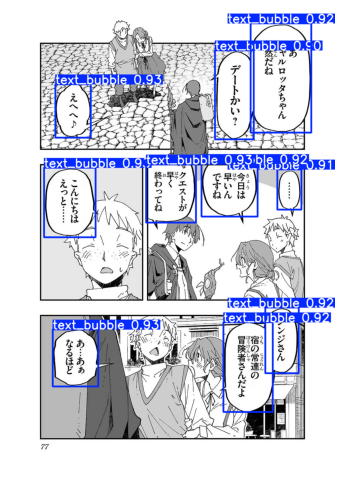

やあシャルロッタちゃん偶然だね
デートかい?
えへへ♪
...
今日は早いんですね
クエストが早く終わってね
こんにちはえっと...
シンジさん
宿の常連の冒険者さんだよ
あ...あぁなるほど


In [3]:
img_path = f'{current_dir}/test.png'

for bubble_img in detect_bubbles(bubble_detector_model, img_path):
    cleaned_img = clean_bubble_edges(bubble_img)
    extract_text(cleaned_img, feature_extractor, model, tokenizer)